In [2]:
import numpy as np
import scipy
import scipy.interpolate
import matplotlib.pyplot as plt
import PIL
import cv2
from pathlib import Path
import PIL.Image

In [3]:
DATA_DIR = Path("data") / "data"


def as_uint8(image):
    image = np.asarray(image)
    if image.dtype == np.uint8:
        return image
    image = image.astype(np.float64, copy=False)
    if image.size and image.min() >= 0.0 and image.max() <= 1.0:
        image = 255.0 * image
    return np.clip(image, 0.0, 255.0).astype(np.uint8)


def _interpolate_channel(raw, cfa, code, method):
    """Interpolate one CFA channel using its regular Bayer sub-grids."""
    if method not in ("linear", "cubic"):
        raise ValueError("method must be 'linear' or 'cubic'")

    raw = np.asarray(raw)
    cfa = np.asarray(cfa)
    if raw.shape != cfa.shape:
        raise ValueError("raw image and CFA mask must have the same shape")

    height, width = raw.shape
    known = cfa == code
    known_rows, known_cols = np.nonzero(known)
    if known_rows.size == 0:
        raise ValueError("CFA code is not present in the mask")

    result = np.zeros((height, width), dtype=np.float64)
    contribution_count = np.zeros((height, width), dtype=np.float64)
    for row_parity in (0, 1):
        for col_parity in (0, 1):
            selected = ((known_rows % 2) == row_parity) & ((known_cols % 2) == col_parity)
            if not np.any(selected):
                continue

            sample_rows = np.unique(known_rows[selected])
            sample_cols = np.unique(known_cols[selected])
            sub_mask = cfa[np.ix_(sample_rows, sample_cols)] == code
            if not np.all(sub_mask):
                continue

            values = raw[np.ix_(sample_rows, sample_cols)].astype(np.float64)
            grid_method = method
            if method == "cubic" and (sample_rows.size < 4 or sample_cols.size < 4):
                grid_method = "linear"

            interpolator = scipy.interpolate.RegularGridInterpolator(
                (sample_rows.astype(np.float64), sample_cols.astype(np.float64)),
                values,
                method=grid_method,
                bounds_error=False,
                fill_value=None,
            )
            query_rows = np.clip(
                np.arange(height, dtype=np.float64),
                sample_rows[0],
                sample_rows[-1],
            )[:, None]
            query_cols = np.clip(
                np.arange(width, dtype=np.float64),
                sample_cols[0],
                sample_cols[-1],
            )[None, :]
            result += interpolator((query_rows, query_cols))
            contribution_count += 1.0

    # Generic fallback for a mask that is not decomposable into Bayer grids.
    if not np.all(contribution_count):
        points = np.column_stack((known_rows, known_cols))
        query_rows, query_cols = np.indices((height, width), dtype=np.float64)
        fallback = scipy.interpolate.griddata(
            points,
            raw[known].astype(np.float64),
            (query_rows, query_cols),
            method=method,
        )
        missing = contribution_count == 0.0
        result[missing] = fallback[missing]
        contribution_count[missing] = 1.0
        still_missing = ~np.isfinite(result)
        if np.any(still_missing):
            nearest = scipy.interpolate.griddata(
                points,
                raw[known].astype(np.float64),
                (query_rows, query_cols),
                method="nearest",
            )
            result[still_missing] = nearest[still_missing]

    result /= np.maximum(contribution_count, 1.0)
    result[known] = raw[known].astype(np.float64)
    return result


def reconstruct_rgb(raw, cfa, method):
    """Return an RGB image for CFA codes 1=R, 2=G and 3=B."""
    channels = [_interpolate_channel(raw, cfa, code, method) for code in (1, 2, 3)]
    rgb = np.stack(channels, axis=-1)
    return np.clip(rgb, 0.0, 255.0)


def show_rgb(ax, image, title):
    ax.imshow(as_uint8(image))
    ax.set_title(title)
    ax.axis("off")


def show_gray(ax, image, title):
    ax.imshow(image, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")


def image_metrics(image, reference):
    """Return MAE and PSNR for two 8-bit-range images."""
    image = np.clip(np.asarray(image, dtype=np.float64), 0.0, 255.0)
    reference = np.asarray(reference, dtype=np.float64)
    if image.shape != reference.shape:
        raise ValueError("images must have the same shape for comparison")
    error = image - reference
    mse = float(np.mean(error * error))
    psnr = float("inf") if mse == 0.0 else float(10.0 * np.log10((255.0 ** 2) / mse))
    return mse, psnr

#psnr will tell how close the image is to the reference and mse to compare actual error.

def print_metrics(label, image, reference):
    mse, psnr = image_metrics(image, reference)
    print(f"{label}: MSE={mse:.4f}, PSNR={psnr:.2f} dB")


## 1A

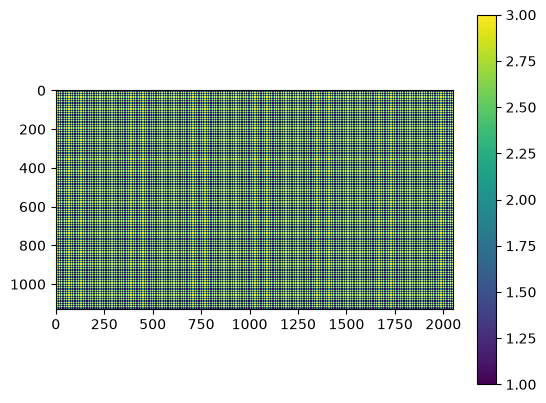

Part (a) - bilinear reconstruction


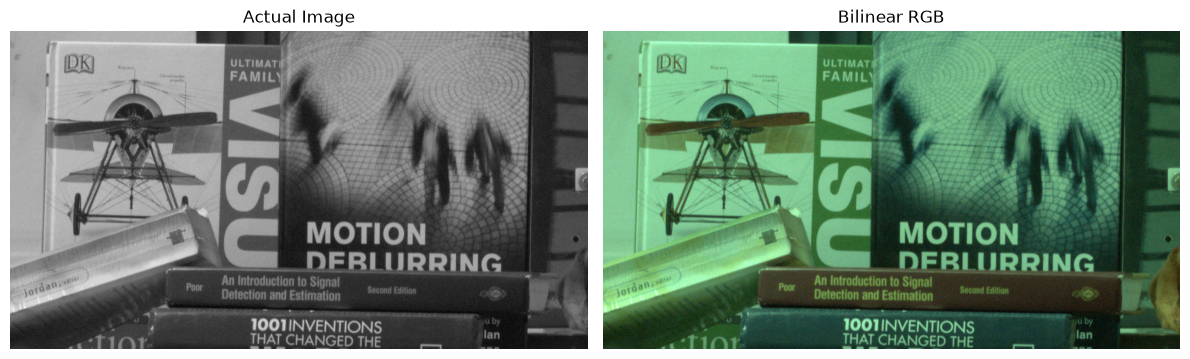

In [4]:
# Part (a): bilinear interpolation (method="linear") for rawimage1.
rawimage1 = np.load(DATA_DIR / "rawimage1.npy")
bayer1 = np.load(DATA_DIR / "bayer1.npy")
plt.imshow(bayer1, interpolation="nearest")
plt.colorbar()
plt.show()
rgb_bilinear = reconstruct_rgb(rawimage1, bayer1, method="linear")

print("Part (a) - bilinear reconstruction")
figure, axes = plt.subplots(1, 2, figsize=(12, 6))
show_gray(axes[0], rawimage1, "Actual Image")
show_rgb(axes[1], rgb_bilinear, "Bilinear RGB")
plt.tight_layout()
plt.show()


## 1B

Part (b) - bicubic reconstruction
Bicubic versus bilinear: MSE=3.8083, PSNR=42.32 dB


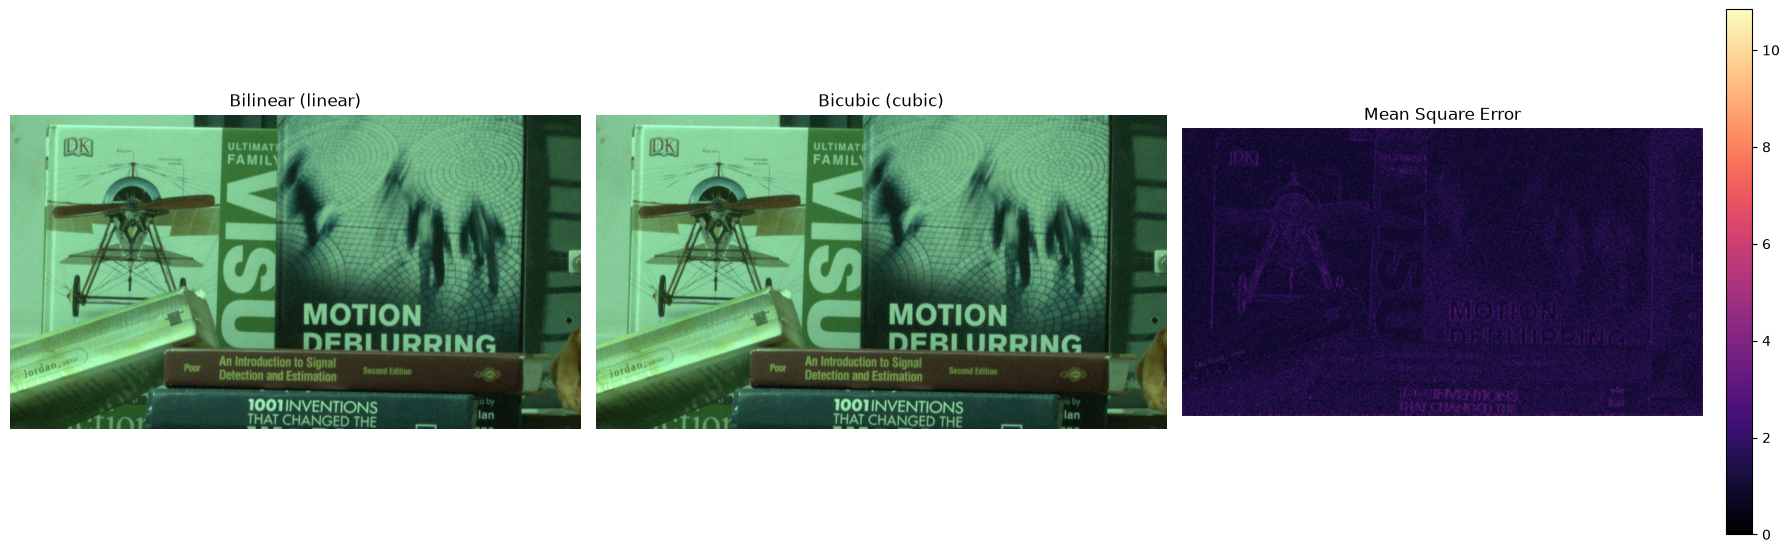

In [5]:
rgb_bicubic = reconstruct_rgb(rawimage1, bayer1, method="cubic")

print("Part (b) - bicubic reconstruction")
print_metrics("Bicubic versus bilinear", rgb_bicubic, rgb_bilinear)

figure, axes = plt.subplots(1, 3, figsize=(18, 6))
show_rgb(axes[0], rgb_bilinear, "Bilinear (linear)")
show_rgb(axes[1], rgb_bicubic, "Bicubic (cubic)")
difference = np.mean(np.abs(rgb_bicubic - rgb_bilinear), axis=2)
image = axes[2].imshow(difference, cmap="magma")
axes[2].set_title("Mean Square Error")
axes[2].axis("off")
figure.colorbar(image, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

Bicubic interpolation usually retains smoother gradients, while the difference is largest near edges and other high-frequency transitions.

## 1C

Part (c) - OpenCV demosaicing
OpenCV versus bilinear: MSE=316.7649, PSNR=23.12 dB
OpenCV versus bicubic: MSE=316.7649, PSNR=23.12 dB


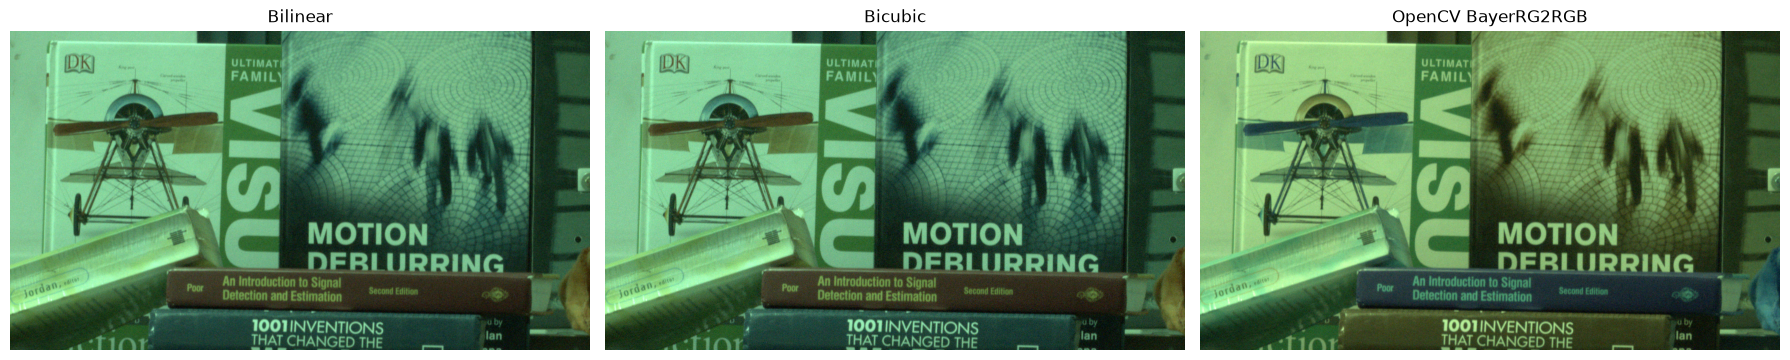

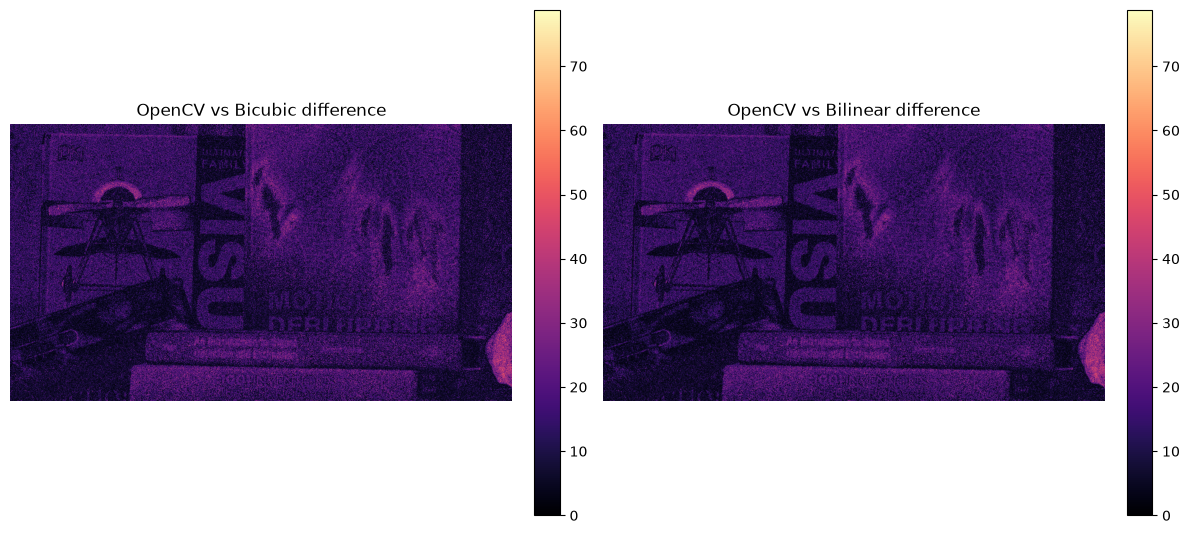

In [6]:
rawimage1_uint8 = as_uint8(rawimage1)
rgb_opencv = cv2.cvtColor(rawimage1_uint8, cv2.COLOR_BayerRG2RGB).astype(np.float64)

print("Part (c) - OpenCV demosaicing")
print_metrics("OpenCV versus bilinear", rgb_opencv, rgb_bilinear)
print_metrics("OpenCV versus bicubic", rgb_opencv, rgb_bilinear)

figure, axes = plt.subplots(1, 3, figsize=(18, 6))
show_rgb(axes[0], rgb_bilinear, "Bilinear")
show_rgb(axes[1], rgb_bicubic, "Bicubic")
show_rgb(axes[2], rgb_opencv, "OpenCV BayerRG2RGB")
plt.tight_layout()
plt.show()

# Difference maps with proper grayscale display and colorbars
diff_opencv_bicubic = np.mean(np.abs(rgb_opencv - rgb_bicubic), axis=2)
diff_opencv_bilinear = np.mean(np.abs(rgb_opencv - rgb_bilinear), axis=2)
figure, axes = plt.subplots(1, 2, figsize=(12, 6))
im0 = axes[0].imshow(diff_opencv_bicubic, cmap="magma")
axes[0].set_title("OpenCV vs Bicubic difference")
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(diff_opencv_bilinear, cmap="magma")
axes[1].set_title("OpenCV vs Bilinear difference")
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 1D: assumptions made by interpolation and consequences when they fail.

1. Each colour channel is locally spatially smooth, so nearby samples
   are representative of a missing sample between them.
2. Colour and intensity do not change abruptly inside an interpolation
   neighbourhood; the CFA pattern and its alignment are known correctly.
3. Samples are not severely clipped or dominated by noise/outliers.

If these assumptions do not hold, linear interpolation can blur edges and
cubic interpolation can produce halos/ringing or overshoot. At colour or
intensity edges, the channels may be interpolated from different sides,
causing zippering and false colours. Wrong CFA alignment swaps colours
throughout the image, while noise or clipping is spread to missing pixels.
Boundary samples can also be less accurate because no samples exist outside
the image; this notebook clamps interpolation queries at the boundary.

## 1E

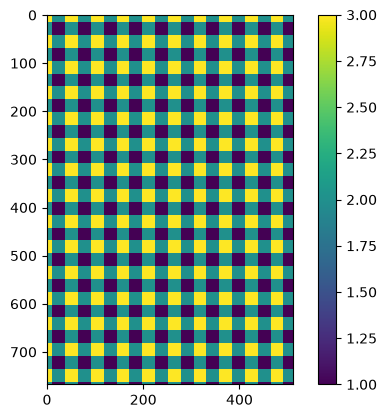

Part (e) - kodim19 bicubic reconstruction


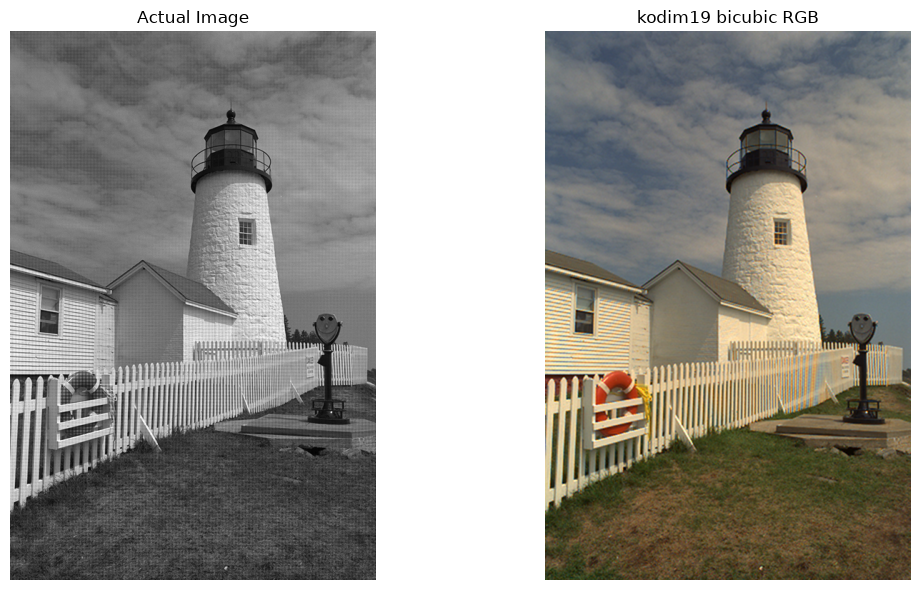

In [7]:
kodim19_raw = np.load(DATA_DIR / "kodim19_raw.npy")
kodim19_cfa = np.load(DATA_DIR / "kodim19_cfa.npy")
plt.imshow(kodim19_cfa, interpolation="nearest")
plt.colorbar()
plt.show()
rgb_kodim19_bicubic = reconstruct_rgb(kodim19_raw, kodim19_cfa, method="cubic")

print("Part (e) - kodim19 bicubic reconstruction")

figure, axes = plt.subplots(1, 2, figsize=(12, 6))
show_gray(axes[0], kodim19_raw, "Actual Image")
show_rgb(axes[1], rgb_kodim19_bicubic, "kodim19 bicubic RGB")
plt.tight_layout()
plt.show()

## 1F

Part (f) - YCrCb chrominance median filtering
Y channel unchanged: True
Before versus After chroma filtering: MSE=8.8431, PSNR=38.66 dB


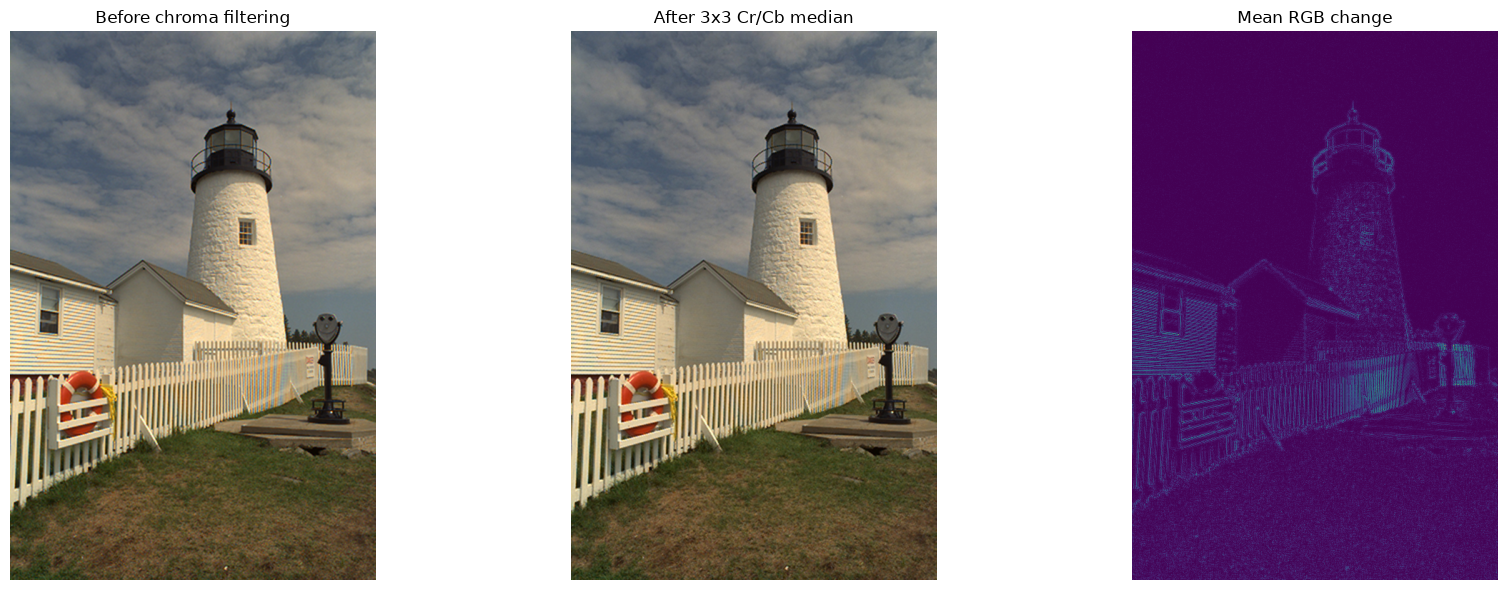

In [8]:
CHROMA_FILTER_SIZE = 3
kodim19_rgb_uint8 = as_uint8(rgb_kodim19_bicubic)
kodim19_ycrcb = cv2.cvtColor(kodim19_rgb_uint8, cv2.COLOR_RGB2YCrCb)
kodim19_ycrcb_filtered = kodim19_ycrcb.copy()
kodim19_ycrcb_filtered[:, :, 1] = cv2.medianBlur(
    kodim19_ycrcb[:, :, 1], CHROMA_FILTER_SIZE
)
kodim19_ycrcb_filtered[:, :, 2] = cv2.medianBlur(
    kodim19_ycrcb[:, :, 2], CHROMA_FILTER_SIZE
)
rgb_kodim19_filtered = cv2.cvtColor(
    kodim19_ycrcb_filtered, cv2.COLOR_YCrCb2RGB
).astype(np.float64)

print("Part (f) - YCrCb chrominance median filtering")
print("Y channel unchanged:", bool(np.array_equal(
    kodim19_ycrcb[:, :, 0], kodim19_ycrcb_filtered[:, :, 0]
)))
print_metrics("Before versus After chroma filtering", kodim19_ycrcb_filtered, kodim19_ycrcb)
figure, axes = plt.subplots(1, 3, figsize=(18, 6))
show_rgb(axes[0], rgb_kodim19_bicubic, "Before chroma filtering")
show_rgb(axes[1], rgb_kodim19_filtered, "After 3x3 Cr/Cb median")
show_rgb(
    axes[2],
    np.mean(np.abs(rgb_kodim19_filtered - rgb_kodim19_bicubic), axis=2),
    "Mean RGB change",
)
plt.tight_layout()
plt.show()


## Reason for choosing 3×3 chroma filter and colour‑edge bleeding

The chroma channels (Cr and Cb) are filtered with a 3×3 median because:

- It is the smallest odd‑sized window that can remove isolated speckle‑like noise.
- Larger windows would start to blur genuine colour transitions, causing **colour‑edge bleeding** – the smearing of colour information across sharp edges, which creates halos or false colours.
- By keeping the window small we suppress noise while preserving edge sharpness; the luminance channel (Y) is left untouched to retain detail.

## 1G

Part (g) - comparison against kodim19_gt.png
Bicubic versus ground truth: MSE=105.8939, PSNR=27.88 dB
Chroma-filtered versus ground truth: MSE=65.6148, PSNR=29.96 dB


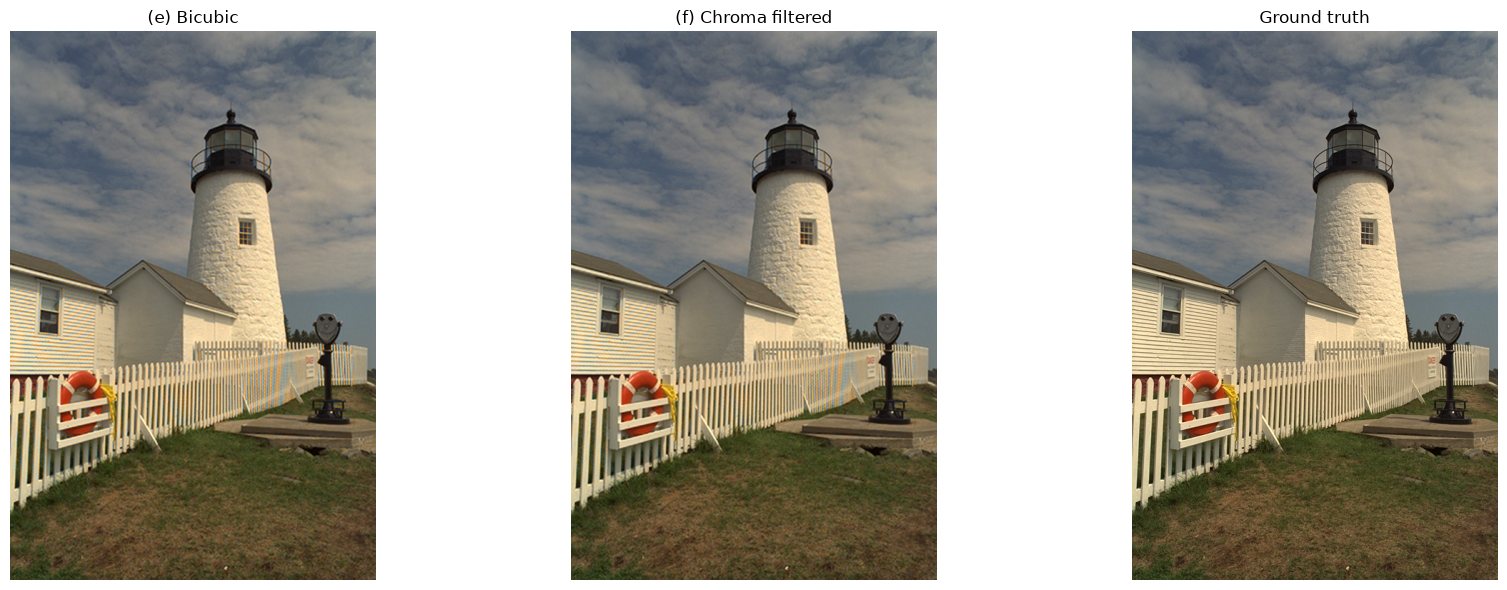

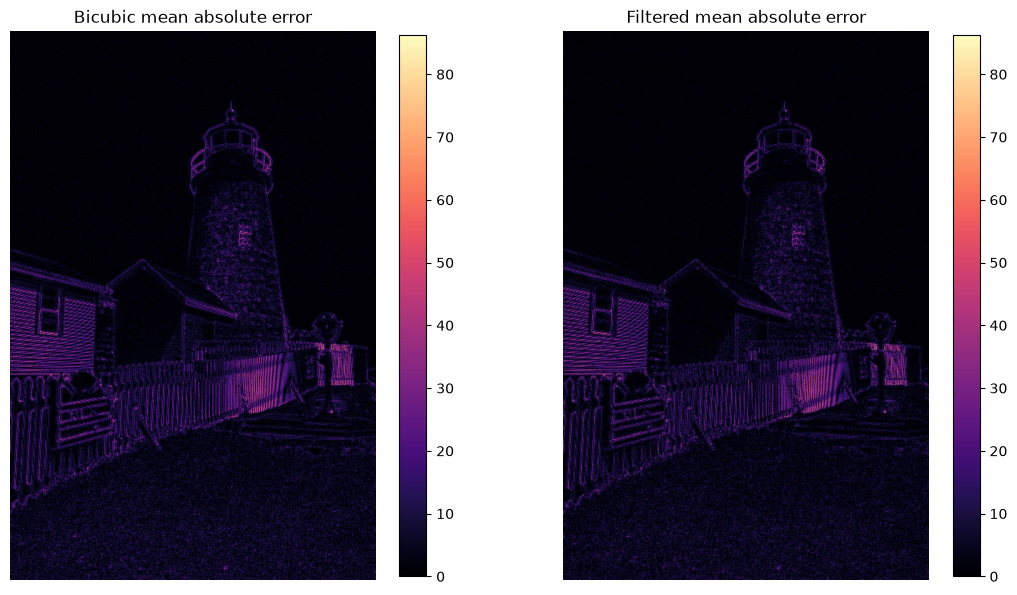

In [12]:
gt_pil = PIL.Image.open(DATA_DIR / "kodim19_gt.png").convert("RGB")
gt_rgb = np.asarray(gt_pil, dtype=np.float64)

print("Part (g) - comparison against kodim19_gt.png")
print_metrics("Bicubic versus ground truth", rgb_kodim19_bicubic, gt_rgb)
print_metrics("Chroma-filtered versus ground truth", rgb_kodim19_filtered, gt_rgb)

bicubic_error = np.mean(np.abs(rgb_kodim19_bicubic - gt_rgb), axis=2)
filtered_error = np.mean(np.abs(rgb_kodim19_filtered - gt_rgb), axis=2)
error_limit = float(max(bicubic_error.max(), filtered_error.max()))

# Figure 1: RGB images side by side
figure1, axes1 = plt.subplots(1, 3, figsize=(18, 6))
show_rgb(axes1[0], rgb_kodim19_bicubic, "(e) Bicubic")
show_rgb(axes1[1], rgb_kodim19_filtered, "(f) Chroma filtered")
show_rgb(axes1[2], gt_rgb, "Ground truth")
plt.tight_layout()
plt.show()

# Figure 2: Error maps
figure2, axes2 = plt.subplots(1, 2, figsize=(12, 6))
im0 = axes2[0].imshow(bicubic_error, cmap="magma", vmin=0.0, vmax=error_limit)
axes2[0].set_title("Bicubic mean absolute error")
axes2[0].axis("off")
plt.colorbar(im0, ax=axes2[0], fraction=0.046, pad=0.04)

im1 = axes2[1].imshow(filtered_error, cmap="magma", vmin=0.0, vmax=error_limit)
axes2[1].set_title("Filtered mean absolute error")
axes2[1].axis("off")
plt.colorbar(im1, ax=axes2[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

The bicubic reconstruction generally preserves smooth detail but can show false colour near sharp edges because each channel is interpolated independently. Filtering Cr and Cb suppresses isolated colour speckles and may lower the error in smooth regions; it can also soften or desaturate fine chromatic detail, so the numerical improvement is image-dependent.